In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.model_selection import GridSearchCV, cross_val_score
import joblib

In [2]:
x_train_pre = joblib.load('x_train_presplit_smote.pkl')
y_train_pre = joblib.load('y_train_presplit_smote.pkl')
x_test_pre  = joblib.load('x_test_presplit_smote.pkl')
y_test_pre  = joblib.load('y_test_presplit_smote.pkl')


In [3]:
knn_model_pre = KNeighborsClassifier(n_neighbors=5)
knn_model_pre.fit(x_train_pre, y_train_pre)

knn_pred_pre = knn_model_pre.predict(x_test_pre)
knn_prob_pre = knn_model_pre.predict_proba(x_test_pre)[:, 1]
print(knn_prob_pre)

[1.  1.  1.  0.2 1.  0.6 0.8 1.  1.  1.  0.2 0.8 1.  1.  0.4 1.  1.  0.4
 1.  1.  0.4 0.  0.  0.2 0.  0.6 1.  1.  1.  0.6 0.4 0.  0.2 0.4 1.  1.
 0.6 0.6 0.6 1.  0.2 0.8 0.  1.  0.4 1.  1.  0.6 0.2 0.4 0.  1.  1.  1.
 1.  0.4 0.6 1.  0.8 0.  0.4 1.  0.  1.  0.4 0.4 0.8 0.  0.  1.  0.4 1.
 0.2 1.  1.  1.  1.  1.  1.  1.  1.  0.4 0.4 0.6 0.  0.8 0.  1.  1.  1.
 1.  0.8 0.2 1.  0.8 0.8 1.  1.  0.  0.2 0.6 1.  1.  1.  0.4 0.  0.8 0.8
 0.4 1.  1.  0.2 1.  1.  0.4 1.  0.  1.  0.4 0.6 1.  1.  0.4 0.4 0.4 0.4
 0.  0.4 1.  0.6 1.  0.6 1.  1.  1.  0.8 0.4 1.  1.  0.  0.2 0.8 0.4 1.
 0.8 1.  0.6 0.2 0.6 0.6 0.4 1.  0.8 0.8 0.  1.  0.4 1.  1.  0.2 0.2 1.
 0.2 1.  1.  1.  1.  1.  1.  0.8 1.  0.6 1.  1.  0.6 0.4 0.4 1.  1.  0.8
 0.4 1.  1.  0.  1.  0.8 0.  0.8 1.  1.  1.  0.2 1.  1.  0.2 0.  0.  1.
 0.4 1.  1.  1.  1.  1.  0.  1.  0.4 0.4 0.  0.8 1.  0.6 1.  0.4 1.  0.4
 0.6 0.  0.6 0.  0.2 1.  0.2 1.  1.  1.  1.  1.  0.2 0.2 1.  1.  0.  1.
 1.  1.  1.  0.8 0.  0.4 0.4 1.  0.4 0.  0.6 0.  1.  1.  0.

In [4]:

knn_accuracy_pre = accuracy_score(y_test_pre, knn_pred_pre)
print("KNN Accuracy (Pre-split SMOTE):", round(knn_accuracy_pre, 4))


KNN Accuracy (Pre-split SMOTE): 0.8306


In [5]:
print("Classification Report\n")
print(classification_report(y_test_pre, knn_pred_pre))


Classification Report

              precision    recall  f1-score   support

           0       0.96      0.69      0.80       339
           1       0.76      0.97      0.85       340

    accuracy                           0.83       679
   macro avg       0.86      0.83      0.83       679
weighted avg       0.86      0.83      0.83       679



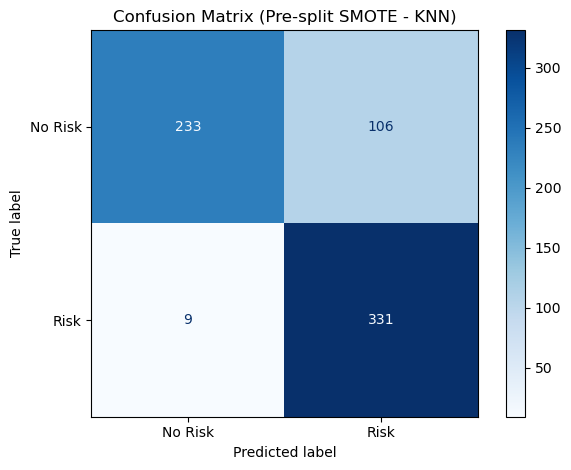

In [6]:
ConfusionMatrixDisplay.from_predictions(
    y_test_pre, knn_pred_pre, display_labels=['No Risk', 'Risk'], cmap='Blues'
)
plt.title("Confusion Matrix (Pre-split SMOTE - KNN)")
plt.tight_layout()
plt.show()


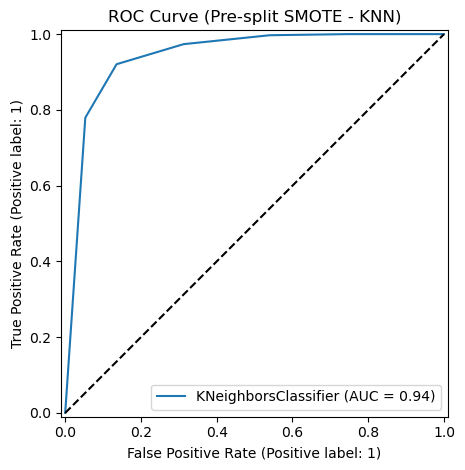

ROC-AUC Score: 0.9422


In [7]:

RocCurveDisplay.from_estimator(knn_model_pre, x_test_pre, y_test_pre)
plt.title('ROC Curve (Pre-split SMOTE - KNN)')
plt.plot([0, 1], [0, 1], 'k--')
plt.tight_layout()
plt.show()

print('ROC-AUC Score:', roc_auc_score(y_test_pre, knn_prob_pre).round(4))


In [8]:
precision_pre = precision_score(y_test_pre, knn_pred_pre)
recall_pre    = recall_score(y_test_pre, knn_pred_pre)
f1_pre        = f1_score(y_test_pre, knn_pred_pre)

print("Precision:", round(precision_pre, 4))
print("Recall   :", round(recall_pre, 4))
print("F1 Score :", round(f1_pre, 4))

Precision: 0.7574
Recall   : 0.9735
F1 Score : 0.852


In [9]:
train_pred_pre = knn_model_pre.predict(x_train_pre)
print("Train Accuracy:", round(accuracy_score(y_train_pre, train_pred_pre), 4))
print("Test Accuracy :", round(knn_accuracy_pre, 4))

Train Accuracy: 0.9034
Test Accuracy : 0.8306


In [10]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}

grid_search_pre = GridSearchCV(
    KNeighborsClassifier(),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_search_pre.fit(x_train_pre, y_train_pre)


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9, 11],
                         'weights': ['uniform', 'distance']},
             scoring='roc_auc')

In [11]:
print("Best Params:", grid_search_pre.best_params_)
best_model_pre = grid_search_pre.best_estimator_

Best Params: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}


In [12]:
best_pred_pre = best_model_pre.predict(x_test_pre)
best_prob_pre = best_model_pre.predict_proba(x_test_pre)[:, 1]
print("Best Model Accuracy:", round(accuracy_score(y_test_pre, best_pred_pre), 4))
print("Best Model ROC-AUC :", roc_auc_score(y_test_pre, best_prob_pre).round(4))


Best Model Accuracy: 0.8689
Best Model ROC-AUC : 0.9738


In [13]:
cv_scores_pre = cross_val_score(knn_model_pre, x_train_pre, y_train_pre, cv=5, scoring='roc_auc')
print("CV ROC-AUC Scores:", cv_scores_pre.round(4))
print("Mean:", cv_scores_pre.mean().round(4), "| Std dev:", cv_scores_pre.std().round(4))


CV ROC-AUC Scores: [0.9244 0.9292 0.9261 0.9393 0.9356]
Mean: 0.9309 | Std dev: 0.0057


In [14]:
joblib.dump(knn_model_pre, 'knn_model_presplit_smote.pkl')
print("Model saved.")

Model saved.
